                   SAMPLE HOUSE DATASET RECORD (FIRST 5 ROWS)          
   Bedrooms_BHK  Kitchens  Floors  Square_Feet Location  Price_Lakhs
0             4         1       1         3887  Village        80.01
1             5         2       2         3749  Village        84.60
2             3         2       1         1039     City        85.52
3             5         2       3         3279  Village        77.91
4             5         2       3         1368     City       116.45

                     MODEL PERFORMANCE REPORT CARD                     
🔹 Linear Regression Engine:
   -> Average Estimation Error : ₹15.72 Lakhs
   -> Model Predictive Accuracy: 89.23%

🔹 Random Forest Regressor:
   -> Average Estimation Error : ₹4.75 Lakhs
   -> Model Predictive Accuracy: 99.20%

🏆 SELECTION CONCLUSION: 'Random Forest Regressor' is chosen as the absolute Best Model.



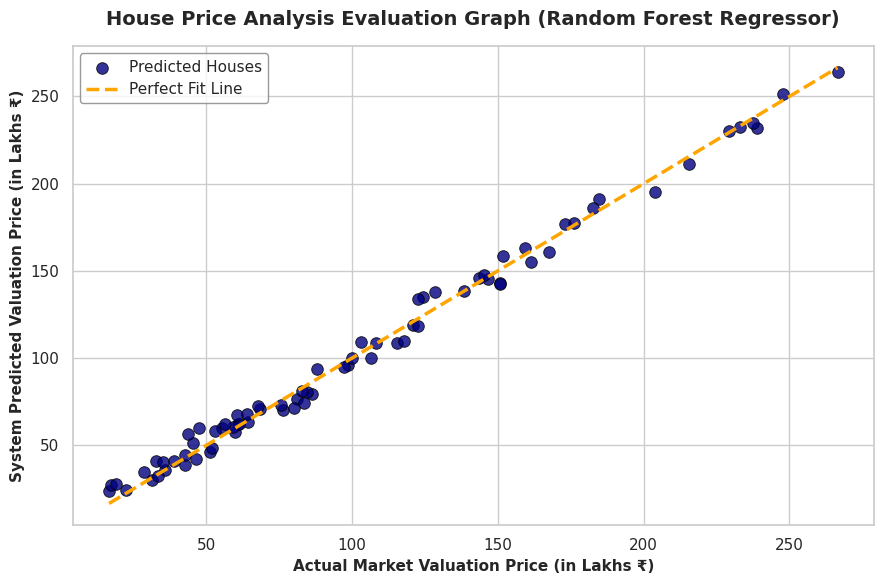

In [1]:
# ==============================================================================
# PROJECT NAME : HOUSE PRICE PREDICTION SYSTEM
# ENVIRONMENT  : PYTHON CORE MACHINE LEARNING (SCIKIT-LEARNING)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Set style for clean visual plots
sns.set_theme(style="whitegrid")
np.random.seed(42)

# ------------------------------------------------------------------------------
# STEP 1: FRAMING THE INDIAN HOUSE PRICE DATASET
# ------------------------------------------------------------------------------
num_samples = 250

dataset_dict = {
    'Bedrooms_BHK': np.random.randint(1, 6, num_samples),         # 1 BHK to 5 BHK
    'Kitchens':     np.random.randint(1, 3, num_samples),         # 1 or 2 Kitchens
    'Floors':       np.random.randint(1, 4, num_samples),         # 1 to 3 Storeys
    'Square_Feet':  np.random.randint(500, 4000, num_samples),    # Built-up Area
    'Location':     np.random.choice(['City', 'Outer City', 'Village'], num_samples)
}

df_house = pd.DataFrame(dataset_dict)

# Mapping real-world Indian real estate pricing baseline factors per Sq. Ft.
# City = Metro Premium, Outer City = Semi-Urban/Suburbs, Village = Rural Area
location_rates = {'City': 6500, 'Outer City': 3500, 'Village': 1500}

# Price valuation mathematical engine (Base cost + Features + Random Market Noise)
df_house['Price_INR'] = (
    df_house['Square_Feet'] * df_house['Location'].map(location_rates) +
    df_house['Bedrooms_BHK'] * 300000 +   # ₹3 Lakhs per extra room
    df_house['Floors'] * 500000 +         # ₹5 Lakhs per floor level
    np.random.normal(0, 250000, num_samples)
)

# Convert pricing scale safely to Indian Lakhs (1 Lakh = 1,00,000 INR) for simple display
df_house['Price_Lakhs'] = (df_house['Price_INR'] / 100000).round(2)
df_house = df_house.drop(columns=['Price_INR'])

print("=======================================================================")
print("                   SAMPLE HOUSE DATASET RECORD (FIRST 5 ROWS)          ")
print("=======================================================================")
print(df_house.head())
print("=======================================================================\n")


# ------------------------------------------------------------------------------
# STEP 2: DATA PREPROCESSING AND 30% TEST-TRAIN SPLITTING
# ------------------------------------------------------------------------------
# Convert text locations to One-Hot Encoded variables (numerical columns)
df_encoded = pd.get_dummies(df_house, columns=['Location'], drop_first=True)

# Separate input attributes (X) from the final Target Price (y)
X = df_encoded.drop(columns=['Price_Lakhs'])
y = df_encoded['Price_Lakhs']

# Explicitly allocating 30% data for evaluation matrix testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)


# ------------------------------------------------------------------------------
# STEP 3: TRAINING IMPLEMENTATION & MODEL EVALUATION
# ------------------------------------------------------------------------------
ml_models = {
    "Linear Regression Engine": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

print("=======================================================================")
print("                     MODEL PERFORMANCE REPORT CARD                     ")
print("=======================================================================")

best_model_score = -1
best_model_name = ""
final_predictions = None

for name, model in ml_models.items():
    # Train the chosen framework
    model.fit(X_train, y_train)

    # Predict output on 30% unseen testing data
    predictions = model.predict(X_test)

    # Calculation of Standard performance errors
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"🔹 {name}:")
    print(f"   -> Average Estimation Error : ₹{mae:.2f} Lakhs")
    print(f"   -> Model Predictive Accuracy: {r2 * 100:.2f}%\n")

    if r2 > best_model_score:
        best_model_score = r2
        best_model_name = name
        final_predictions = predictions

print(f"🏆 SELECTION CONCLUSION: '{best_model_name}' is chosen as the absolute Best Model.")
print("=======================================================================\n")


# ------------------------------------------------------------------------------
# STEP 4: DIAGNOSTIC SYSTEM VISUALIZATION (Actual vs. Predicted Plot)
# ------------------------------------------------------------------------------
plt.figure(figsize=(9, 6))

# Generate scatter visual graph for model prediction insights
sns.scatterplot(x=y_test, y=final_predictions, color='navy', s=70, alpha=0.8, edgecolor='black', label='Predicted Houses')

# Draw an Ideal Prediction Benchmark reference vector line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='orange', linestyle='--', linewidth=2.5, label='Perfect Fit Line')

# Graphical chart layout configurations
plt.title(f'House Price Analysis Evaluation Graph ({best_model_name})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Market Valuation Price (in Lakhs ₹)', fontsize=11, fontweight='bold')
plt.ylabel('System Predicted Valuation Price (in Lakhs ₹)', fontsize=11, fontweight='bold')
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='gray')
plt.tight_layout()

# Prompt structural output graph display window
plt.show()